# 📊 Data Analysis & Statistics Interview Handbook

Этот ноутбук — твой гид по подготовке данных и статистике по стандартам учебника Яндекса. Мы разберем всё: от манипуляций в Pandas до проверки гипотез.

---

## Блок 1: Pandas Ninja (Основные манипуляции)

### 🔎 Ключевые методы
- **`df.describe()` & `df.info()`**: Базовая статистика и инфо по типам.
- **`df.value_counts()`**: Распределение категорий (аналог `GROUP BY ... COUNT` в SQL).
- **`df.nunique()`**: Количество уникальных значений в каждой колонке.
- **`df.duplicated().sum()`**: Поиск и удаление (`drop_duplicates()`) полных дублей.
- **`df.isna().sum()`**: Пoиск пропущенных значений.
- **`df.fillna()`**: Заполнение пропусков (константой, средним, медианой и т.д.).
- **`df.groupby().agg()`**: Группировка с несколькими агрегациями.
- **`pd.pivot_table()`**: Сводные таблицы.
- **`df.apply()`**: Применение кастомной логики.
- **`pd.merge()`**: Объединение таблиц (inner, left, right, outer).

In [23]:
import pandas as pd
import numpy as np

# 1. Создание и инфо
data = {
    'user_id': [1, 2, 2, 3, 4, 5, 5],
    'group': ['A', 'A', 'A', 'B', 'B', 'B', 'C'],
    'value': [10, 15, 15, 20, 10, np.nan, 30],
    'category': ['X', 'Y', 'Y', 'X', 'Y', 'X', 'X']
}
df = pd.DataFrame(data)

print("--- df.info() ---")
print(df.info())

print("\n--- df.describe() ---")
print(df.describe().T)

# 2. Дубликаты и пропуски
print(f"\nДубликаты: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Пропуски:\n{df.isna().sum()}")
df['value'] = df['value'].fillna(df['value'].mean())

# 3. Агрегации и Merge
summary = df.groupby('group').agg({'value': ['mean', 'nunique']})
print("\nАгрегация:")
print(summary)

# 4. Pivot Table
pivot = df.pivot_table(index='group', columns='category', values='value', aggfunc='sum')
print("\nСводная таблица:")
print(pivot)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   7 non-null      int64  
 1   group     7 non-null      object 
 2   value     6 non-null      float64
 3   category  7 non-null      object 
dtypes: float64(1), int64(1), object(2)
memory usage: 356.0+ bytes
None

--- df.describe() ---
         count       mean       std   min    25%   50%    75%   max
user_id    7.0   3.142857  1.573592   1.0   2.00   3.0   4.50   5.0
value      6.0  16.666667  7.527727  10.0  11.25  15.0  18.75  30.0

Дубликаты: 1
Пропуски:
user_id     0
group       0
value       1
category    0
dtype: int64

Агрегация:
           value        
            mean nunique
group                   
A      12.500000       2
B      15.666667       3
C      30.000000       1

Сводная таблица:
category     X     Y
group               
A         10.0  15.0
B         37.

--- 
## Блок 2: Очистка данных и Выбросы (Outliers)

### 🔎 Теория (Z-score)
**Z-score (Правило 3-х сигм):** Показывает, на сколько стандартных отклонений $(\sigma)$ значение отстоит от среднего $(\mu)$.
$$Z = \frac{x - \mu}{\sigma}$$
Если $|Z| > 3$, значение считается выбросом.

In [24]:
from scipy import stats

# Генерация данных с выбросом
vals = np.array([10, 12, 12, 13, 12, 11, 100]) # 100 - явный выброс
z_scores = np.abs(stats.zscore(vals))
outliers = vals[z_scores > 2] # Возьмем порог 2 для наглядности
print(f"Выбросы: {outliers}")

Выбросы: [100]


--- 
## Блок 3: Feature Engineering (Кодирование и Масштабирование)

- **One-Hot Encoding:** Для номинальных признаков (нет порядка).
- **Ordinal Encoding:** Когда есть порядок (например, холодный -> теплый -> горячий).
- **StandardScaler:** Центрирует данные (среднее=0, дисперсия=1). Чувствителен к выбросам!
- **MinMaxScaler:** Сжимает в диапазон [0, 1].

In [25]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# --- 1. One-Hot Encoding (Pandas) ---
df_encoded = pd.get_dummies(df, columns=['category'], prefix='cat')
print("OHE результат (первые строки):")
print(df_encoded.head(2))

# --- 2. Ordinal Encoding (Кастомный/Sklearn) ---
# Кодируем образование: 'low' < 'medium' < 'high'
size_map = {'A': 0, 'B': 1, 'C': 2}
df['group_rank'] = df['group'].map(size_map)

# --- 3. Scaling ---
scaler = StandardScaler()
df['value_scaled'] = scaler.fit_transform(df[['value']])
print("\nДаные после StandardScaler (value_scaled):")
print(df[['value', 'value_scaled']].head(3))

OHE результат (первые строки):
   user_id group  value  cat_X  cat_Y
0        1     A   10.0   True  False
1        2     A   15.0  False   True

Даные после StandardScaler (value_scaled):
   value  value_scaled
0   10.0     -1.024695
1   15.0     -0.292770
3   20.0      0.439155


--- 
## Блок 4: Визуализация данных (Seaborn)

- **Boxplot:** Лучший способ увидеть медиану, квартили и выбросы.
- **Heatmap:** Идеален для корреляционных матриц.

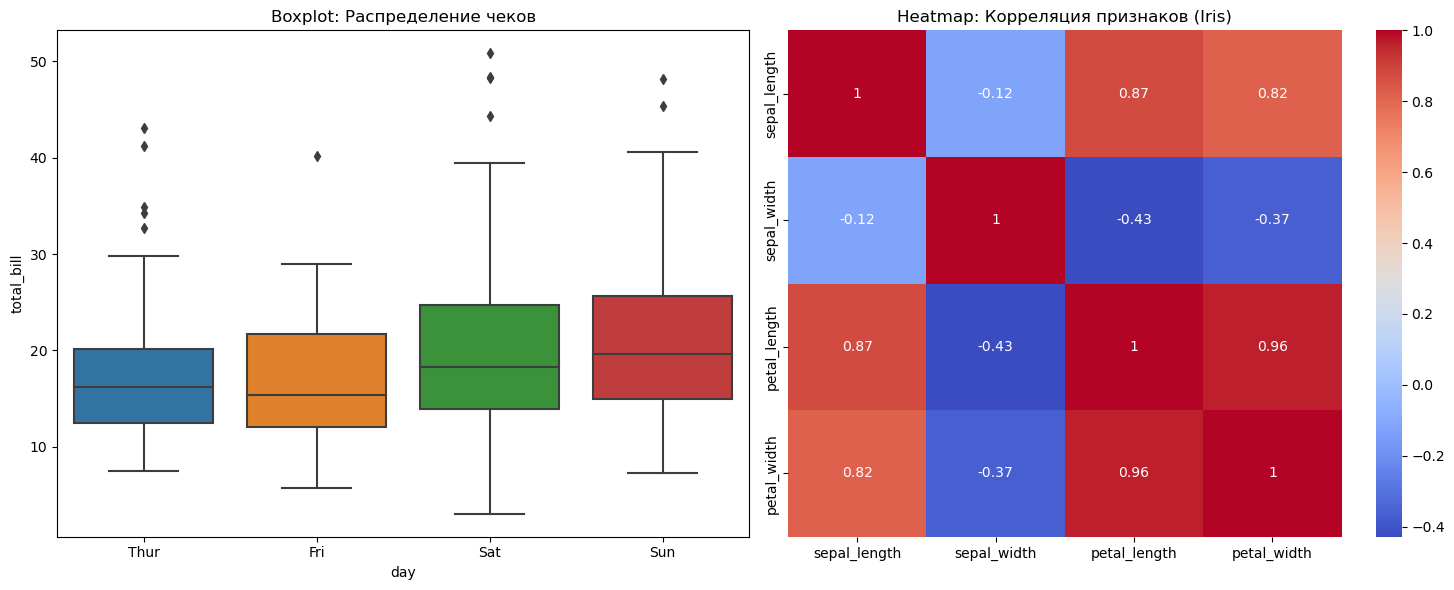

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Boxplot - поиск выбросов
tips = sns.load_dataset("tips")
sns.boxplot(x="day", y="total_bill", data=tips, ax=axes[0])
axes[0].set_title("Boxplot: Распределение чеков")

# 2. Heatmap - корреляция признаков
# Загрузим датасет с числами для корреляции
iris = sns.load_dataset("iris")
sns.heatmap(iris.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title("Heatmap: Корреляция признаков (Iris)")

plt.tight_layout()
plt.show()

--- 
## Блок 5: Статистические тесты

### 🔎 Подробный разбор
1. **Нормальность (Шапиро-Уилк, Колмогоров-Смирнов с поправкой Лиллиефорса):** Показывает, насколько сильно распределение отклоняется от идеальной кривой Гаусса. $p < 0.05$ — распределение **статистически значимо** отличается от нормального. *Примечание: Тест K-S без поправки Лиллиефорса обычно не рекомендуется для проверки нормальности с оцененными параметрами.*
2. **t-test (Студента):** Сравнивает средние значения двух независимых групп. Требует нормальности данных и равенства дисперсий.
3. **U-тест Манна-Уитни:** Ранговый тест. Используется, когда данных мало или они не распределены нормально. Сравнивает распределения, а не средние.
4. **Хи-квадрат (Chi-Squared):** Используется для проверки связи между категориальными переменными (например, 'пол' и 'покупка товара').

In [27]:
from scipy.stats import kstest, norm, chi2_contingency
import numpy as np
# --- 1. Проверка на нормальность (KS-test) ---
data_norm = np.random.normal(0, 1, 100)
stat, p = kstest(data_norm, 'norm')
print(f"KS-test (Normal data) p-value: {p:.4f}")

# --- 2. Хи-квадрат (Зависимость признаков) ---
# Таблица сопряженности: [Женщины, Мужчины] x [Купили, Не купили]
contingency_table = [
    [20, 30], # Купили
    [40, 10]  # Не купили
]
chi2, p_chi2, dof, ex = chi2_contingency(contingency_table)
print(f"Chi-square p-value: {p_chi2:.4f} (связь есть, если p < 0.05)")

KS-test (Normal data) p-value: 0.6931
Chi-square p-value: 0.0001 (связь есть, если p < 0.05)


In [28]:
from scipy.stats import ttest_ind, mannwhitneyu

group1 = [20, 22, 19, 20, 22]
group2 = [30, 28, 32, 29, 31]

stat, p = ttest_ind(group1, group2)
print(f"t-test p-value: {p:.5f} (p < 0.05 означает значимую разницу)")

t-test p-value: 0.00001 (p < 0.05 означает значимую разницу)


--- 
## Блок 6: Небалансные классы (Imbalanced Classes)

### 🔎 Как меняются данные?
- **Resampling (SMOTE)**: Если у нас было 95% '0' и 5% '1', SMOTE создаст новые синтетические '1', пока их не станет, например, 50/50. Классы "выравниваются", но появляется риск переобучения.
- **Class Weights**: Мы не меняем данные, но говорим модели: "Ошибка на '1' стоит в 20 раз дороже, чем на '0'".

#### Пример изменения баланса:
- До: {0: 1000, 1: 50}
- После Oversampling: {0: 1000, 1: 1000}
- После Undersampling: {0: 50, 1: 50}

### 📝 Практические задачи

1. **Pandas:** Сгруппируй данные о продажах по месяцам и посчитай сумму и среднее за каждый месяц.
2. **Stats:** Проверь гипотезу о том, что средний чек по выходным больше, чем по будням (используй датасет `tips`).
3. **Outliers:** Напиши функцию для удаления выбросов по методу межквартильного размаха (IQR).

### ✅ Решения практических задач

<details>
<summary><b>Задача 1: Pandas (Группировка по месяцам)</b></summary>

```python
# Переводим колонку в формат даты
df['date'] = pd.to_datetime(df['date'])
# Группируем по месяцу (или периоду)
monthly_stats = df.groupby(df['date'].dt.to_period('M'))['sales'].agg(['sum', 'mean'])
```
</details>

<details>
<summary><b>Задача 2: Stats (Гипотеза по чекам в tips)</b></summary>

```python
from scipy.stats import ttest_ind
import seaborn as sns

tips = sns.load_dataset('tips')
# Определяем выходные (Sat, Sun)
weekend = tips[tips['day'].isin(['Sat', 'Sun'])]['total_bill']
workday = tips[~tips['day'].isin(['Sat', 'Sun'])]['total_bill']

# Односторонний t-тест (H1: на выходных больше)
t_stat, p_val = ttest_ind(weekend, workday, alternative='greater')
print(f"p-value: {p_val:.4f}")
```
</details>

<details>
<summary><b>Задача 3: Outliers (Метод IQR)</b></summary>

```python
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
```
</details>

---
## 🎯 Реальные вопросы с собеседований (Data Analyst / Junior DS)

### 🎤 Вопросы по данным:
1. **Data Leakage (Утечка данных):** Вы решили нормализовать данные с помощью `StandardScaler.fit_transform()` ко всему датасету (до разделения на train/test). Почему это грубейшая ошибка и к чему она приведет?
2. **Коллинеарность:** Что такое мультиколлинеарность признаков? Как ее обнаружить (VIF, Heatmap) и почему она ломает интерпретируемость линейной регрессии?
3. **Парадокс Симпсона:** Вы провели А/В тест. В группе А конверсия выросла в каждом из городов отдельно. Но если сложить все города вместе, конверсия группы B оказалась выше. Возможно ли это математически? (Спойлер: да, из-за разного размера выборок).

### 💻 Задачи по Pandas:
1. **Скользящее среднее:** Как с помощью pandas посчитать скользящее среднее (Moving Average) за 7 дней (`rolling`).
2. **Умный FillNA:** Как заполнить пропуски в колонке `Age` медианным значением, вычисленным отдельно для каждой группы `Gender`?

### ✅ Ответы на вопросы

<details>
<summary><b>Ответ 1: Data Leakage (Утечка данных)</b></summary>

**Почему это ошибка:** Если применить `StandardScaler` ко всему датасету до разделения, то среднее и дисперсия будут вычислены с учетом тестовых данных. Модель "подглядит" в тестовую выборку. Это приведет к переобучению и завышенной оценке качества на тесте.
**Правильно:** Сначала `train_test_split()`, затем обучаем скейлер только на `train` (`fit_transform`) и применяем к `test` (`transform`).
</details>

<details>
<summary><b>Ответ 2: Мультиколлинеарность</b></summary>

**Что это:** Сильная корреляция независимых признаков между собой. 
**Как найти:** Корреляционная матрица (Heatmap) или VIF (Variance Inflation Factor). Если VIF > 10, коллинеарность высокая.
**Почему ломает регрессию:** Веса (коэффициенты) линейной регрессии становятся нестабильными и теряют интерпретируемость (невозможно понять, какой признак вносит реальный вклад). Модель может даже поменять знак коэффициента на нелогичный.
</details>

<details>
<summary><b>Ответ 3: Парадокс Симпсона</b></summary>

**Суть:** Закономерность, наблюдаемая для разных групп данных, исчезает или меняется на противоположную при объединении этих групп.
**Возможно ли математически:** Да. Возникает, когда присутствуют скрытые переменные (confounders) или выборки сильно несбалансированы по размеру. Вывод: необходимо анализировать данные в разрезе релевантных когорт, а не только в агрегированном виде.
</details>

<details>
<summary><b>Ответ 4: Pandas Скользящее среднее и FillNA</b></summary>

**Скользящее среднее (MA 7 дней):**
```python
df['ma_7'] = df['sales'].rolling(window=7).mean()
```
**Умный FillNA (медиана по группе):**
```python
df['Age'] = df.groupby('Gender')['Age'].transform(lambda x: x.fillna(x.median()))
```
</details>

---
## 🧠 Частые дополнительные вопросы (на понимание)

<details>
<summary><b>1. Что такое p-value простыми словами?</b></summary>

**P-value** — это вероятность получить такие же или еще более экстремальные различия между группами при условии, что нулевая гипотеза верна (т.е. разницы на самом деле нет). Если p-value < 0.05, мы говорим: "Шанс получить такой результат случайно меньше 5%. Значит, скорее всего, разница реальна".
</details>

<details>
<summary><b>2. Корреляция не означает причинно-следственную связь. Почему?</b></summary>

Две переменные могут двигаться синхронно не потому, что одна вызывает другую, а потому, что на них обеих влияет **третий, скрытый фактор**. Классический пример: рост продаж мороженого и рост смертей от тепловых ударов коррелируют, но причиной обоих явлений служит жаркая погода.
</details>